#### Install Required libraries

In [1]:
# ! pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np # the numpy module is used for numerical operations
import pandas as pd #   the pandas is used for data manipulation and analysis which is in structured format
import matplotlib.pyplot as plt # the matplotlib is used for data visualizations and plotting graphs
import seaborn as sns # the seaborn is used for statistical data visualization built on top of matplotlib

#### Importing the sklearn and its packages for data processing

In [3]:
from sklearn.model_selection import train_test_split # to split the data into training and testing sets in the ratio of 80:20 respectively
from  sklearn.preprocessing import StandardScaler #  to standardize the features by removing the mean and scaling to unit variance    

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
# importing the dataset
dataset = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\Celebal_internship\WEEK3\data\Country-data.csv')

In [5]:
df=pd.DataFrame(dataset) # converting the dataset into DataFrame for better data manipulation and analysis
print(df)

                 country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2       5.82    553  
1         4.49   

#### understanding the dataset

In [6]:
#  First 5 rows in the dataset
print(f'First 5 rows in the dataset:\n{df.head()}')
print('~'*50)
print(f'Last 5 rows in the dataset:\n{df.tail()}')
print('~'*50)
rows, columns=df.shape # to get the number of rows and columns in the dataset
print(f'Number of rows = {rows}, Number of columns = {columns}')
print('~'*50)
print(f'Column names in the dataset:\n{df.columns}')
print('~'*50)
print(f'Informatio about the dataset:\n{df.info()}')
print('~'*50)
print(f'Statictical summary of the dataset:\n{df.describe()}')
print('~'*50)

First 5 rows in the dataset:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Last 5 rows in the dataset:
       country  child_mort  exports  health  imports  income  inflation  \
162    Vanuatu        29.2     46.6    5.25     52.7    2950       2.62   
163  Venezuela        17.1     28.5    

In [7]:
#### Features and target variable in the dataset
print(f'Columns in the dataset:\n{df.columns}')

Columns in the dataset:
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


- Insight: The dataset contains the columns:
1. country - Name of the country
2. child_mort - Death of children under 5 years of age per 1000 live birth
3. exports - Exports of goods and services per capita. Given as %age of the GDP per capita
4. health - Total health spending per capita. Given as %age of GDP per capita
5. imports - Imports of goods and services per capita. Given as %age of the GDP per capita
5. income - Net income per person
6. inflation - The measurement of the annual growth rate of the Total GDP
7. life_expec - The average number of years a new born child would live if the current mortality patterns are to rem...
8. total_fer - The number of children that would be born to each woman if the current age-fertility rates remain th...
9. gdpp - The GDP per capita. Calculated as the Total GDP divided by the total population.

In [8]:
# numerical columns in the dataset
numerical_cols= df.select_dtypes(include=['int64', 'float64'])
print(f'Numerical columns in the dataset:\n{numerical_cols.columns}')

Numerical columns in the dataset:
Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


- Insight: The numerical columns in the dataset are 
1. child_mort
2. exports
3. health
4. imports
5. income
6. inflation
7. life_expec
8. total_fer
9. gdpp

In [9]:
# categorical columns in the dataset
categorical_cols= df.select_dtypes(include=['object', 'bool'])
print(f'Categorical columns in the dataset:\n{categorical_cols.columns}')

Categorical columns in the dataset:
Index(['country'], dtype='object')


- Insight: The categorical columns in the dataset are 
1. country

In [10]:
# columns in the list format
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [11]:
# finding out the unique values in the categorical columns
for col in  categorical_cols:
    unique_values = df[col].unique()
    print(f'Unique values in the columns {col}:\n{unique_values}')
    print('~'*50)

Unique values in the columns country:
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cyprus' 'Czech Republic' 'Denmark' 'Dominican Republic'
 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana'
 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel'
 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'Kiribati'
 'Kuwait' 'Kyrgyz Republic' 'Lao' 'La

In [12]:
print("Number of countries: ",  len(set(df['country'])))

Number of countries:  167


- Insight: There are `167` countries in the dataset

In [13]:
# missing values
print(f'Missing Values in the dataset:\n{df.isnull().sum()}')
# missing value in percentages
print(f'Missing values in percentage:\n{df.isnull().mean()*100}')

Missing Values in the dataset:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
Missing values in percentage:
country       0.0
child_mort    0.0
exports       0.0
health        0.0
imports       0.0
income        0.0
inflation     0.0
life_expec    0.0
total_fer     0.0
gdpp          0.0
dtype: float64


- Insight: There are no missing values in the dataset

In [14]:
# Create a copy of the DataFrame to avoid modifying the original data
df = df.copy()

# Standardize column names:
# - Remove leading/trailing spaces
# - Convert all names to lowercase for consistency
df.columns = [c.strip().lower() for c in df.columns]

# Remove duplicate rows from the DataFrame
df = df.drop_duplicates()

# Convert all columns except 'country' to numeric data types
# Invalid values will be replaced with NaN
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Identify all numeric columns (excluding the categorical 'country' column)
numeric_cols = [c for c in df.columns if c != 'country']

# Fill missing values in numeric columns with the median of each column
# Median is robust to outliers and helps preserve the data distribution
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Display the count of missing values remaining in each column
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

### Data Cleaning/ Data Preprocessing

In [15]:
# handling the missing values
print(f"missing values in the dataset before handling them:\n{df.isnull().sum()}")

missing values in the dataset before handling them:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


- Insight: As there are no missing values there is no need for the process of handing the missing values

In [16]:
# removing the duplicate in the dataset
print(f'Number of duplicate rows in the dataset:\n{df.duplicated().sum()}')

Number of duplicate rows in the dataset:
0


- Insight: As there are no duplicate rows in the dataset there is no need or process of handling them

In [17]:
# to fix the Data types
print((f'Data types before fixing them:\n{df.dtypes}'))

Data types before fixing them:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


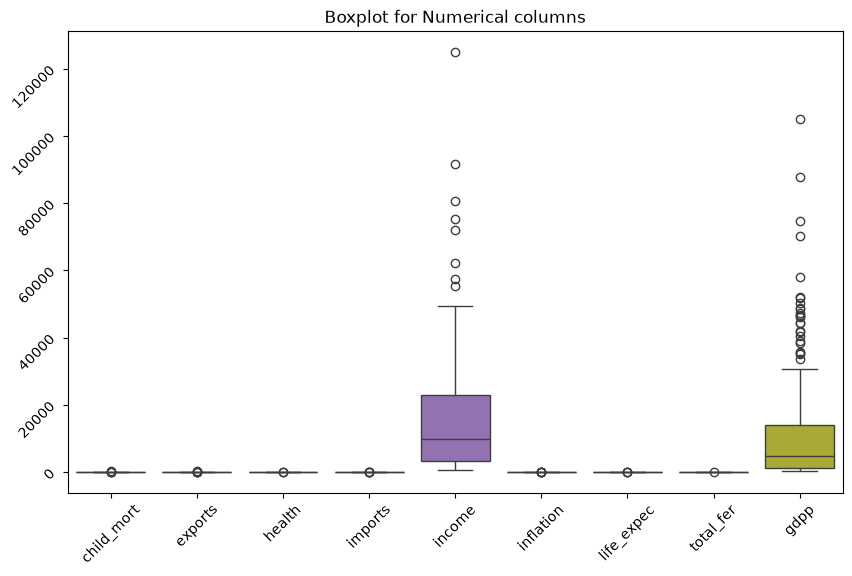

In [18]:
# handling the outliers in the dataset
plt.figure(figsize=(10, 6))
plt.title('Boxplot for Numerical columns')
sns.boxplot(data=df[numerical_cols.columns])
plt.xticks(rotation=45) # to rotate the x-axis labels by  45 degrees for better visibility
plt.yticks(rotation=45) # to rotate the y-axis labels by  45 degrees for better visibility
plt.show()

In [19]:
# represnting the outliers in the dataset in the numerical form
for col in numerical_cols.columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[df[col] < lower_bound][col].tolist() + df[df[col] >upper_bound][col].tolist()
    print(f'Outliers in the `{col}` column: \n{outliers}')

Outliers in the `child_mort` column: 
[149.0, 150.0, 208.0, 160.0]
Outliers in the `exports` column: 
[103.0, 175.0, 153.0, 93.8, 200.0]
Outliers in the `health` column: 
[14.2, 17.9]
Outliers in the `imports` column: 
[142.0, 154.0, 108.0, 174.0]
Outliers in the `income` column: 
[80600, 75200, 91700, 62300, 125000, 72100, 55500, 57600]
Outliers in the `inflation` column: 
[24.9, 39.2, 104.0, 26.5, 45.9]
Outliers in the `life_expec` column: 
[47.5, 32.1, 46.5]
Outliers in the `total_fer` column: 
[7.49]
Outliers in the `gdpp` column: 
[51900, 46900, 44400, 35300, 47400, 58000, 46200, 40600, 41800, 41900, 48700, 35800, 44500, 38500, 105000, 50300, 33700, 87800, 70300, 46600, 52100, 74600, 35000, 38900, 48400]


#### checking for the skewness of the data in order to treat the outliers

In [20]:
skew_df = pd.DataFrame({
    'Feature': numerical_cols.columns,
    'Skewness': numerical_cols.skew().values
})

skew_df = skew_df.sort_values(by='Skewness', ascending=False)

print(skew_df)

      Feature  Skewness
5   inflation  5.154049
1     exports  2.445824
4      income  2.231480
8        gdpp  2.218051
3     imports  1.905276
0  child_mort  1.450774
7   total_fer  0.967092
2      health  0.705746
6  life_expec -0.970996


In [21]:
def skew_category(x):
    if abs(x) < 0.5:
        return "Approximately Symmetric"
    elif abs(x) < 1:
        return "Moderately Skewed"
    else:
        return "Highly Skewed"

skew_df['Category'] = skew_df['Skewness'].apply(skew_category)

print(skew_df)

      Feature  Skewness           Category
5   inflation  5.154049      Highly Skewed
1     exports  2.445824      Highly Skewed
4      income  2.231480      Highly Skewed
8        gdpp  2.218051      Highly Skewed
3     imports  1.905276      Highly Skewed
0  child_mort  1.450774      Highly Skewed
7   total_fer  0.967092  Moderately Skewed
2      health  0.705746  Moderately Skewed
6  life_expec -0.970996  Moderately Skewed


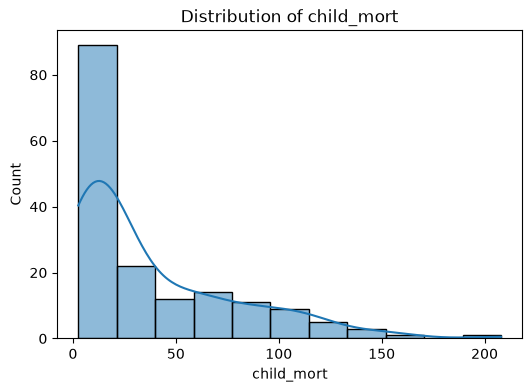

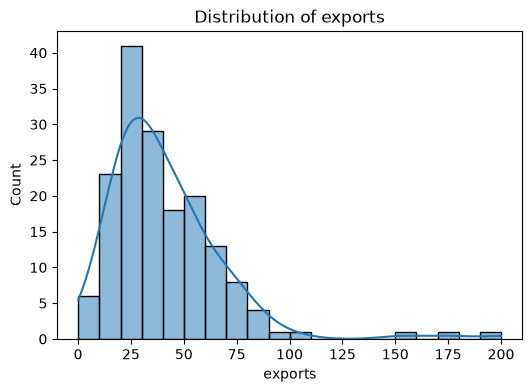

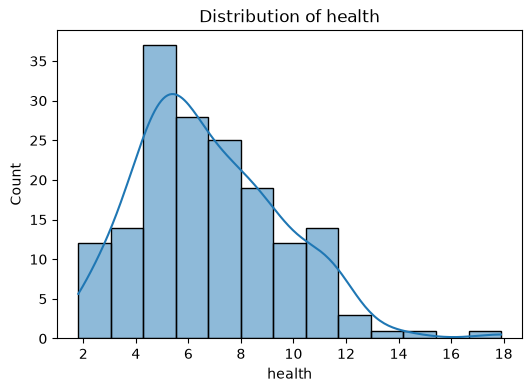

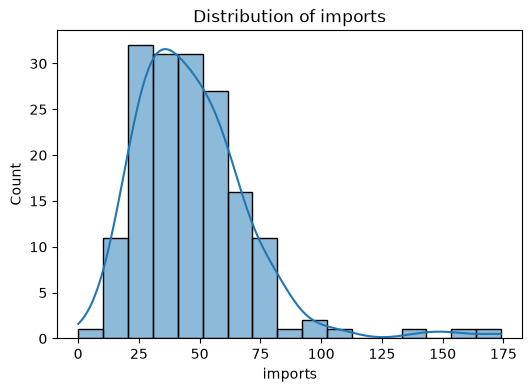

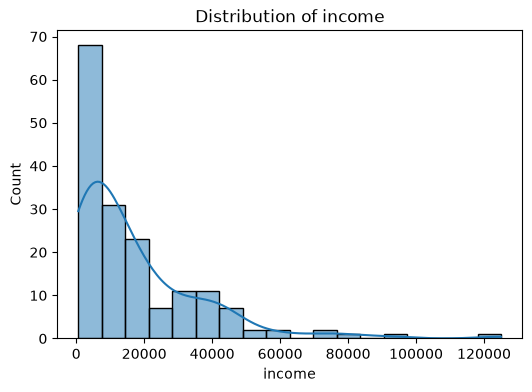

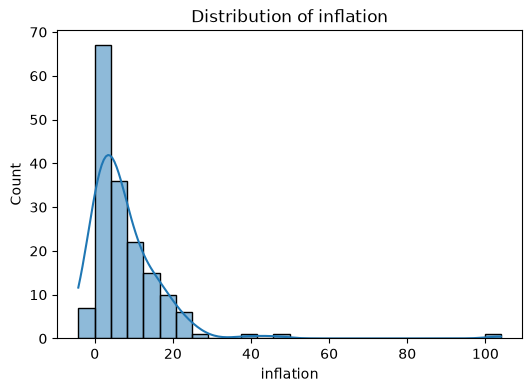

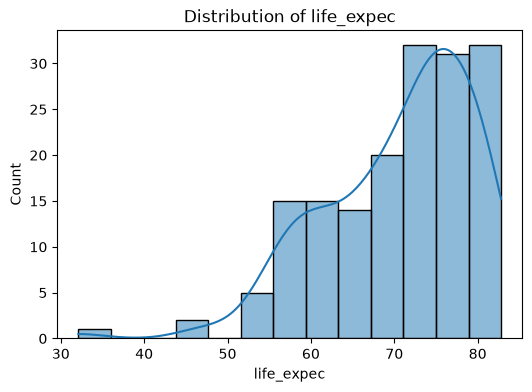

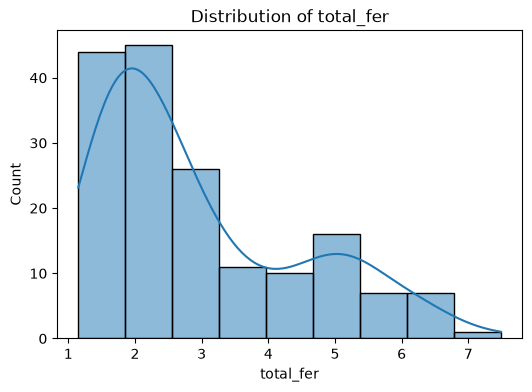

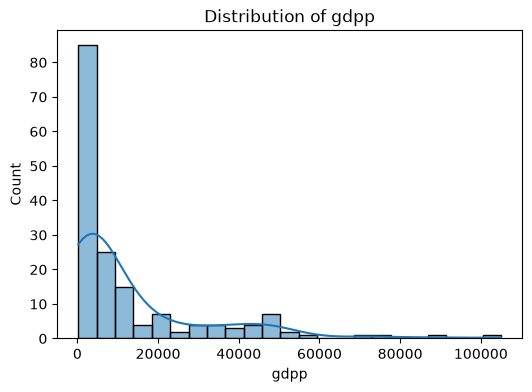

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in numerical_cols.columns:
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        df[col],
        kde=True
    )
    
    plt.title(f'Distribution of {col}')
    plt.show()

In [23]:
# to check which columns need log transformation to treat or handle the outliers

# Calculate skewness
skewness = numerical_cols.skew()

print(skewness.sort_values(ascending=False))

highly_skewed = skewness[abs(skewness) > 1]

print("Highly Skewed Features:")
print(highly_skewed)

inflation     5.154049
exports       2.445824
income        2.231480
gdpp          2.218051
imports       1.905276
child_mort    1.450774
total_fer     0.967092
health        0.705746
life_expec   -0.970996
dtype: float64
Highly Skewed Features:
child_mort    1.450774
exports       2.445824
imports       1.905276
income        2.231480
inflation     5.154049
gdpp          2.218051
dtype: float64


In [24]:
import numpy as np

skewed_cols = [
    'child_mort',
    'exports',
    'imports',
    'income',
    'inflation',
    'gdpp'
]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [25]:
print(df[skewed_cols].skew())

child_mort    0.066160
exports      -1.088961
imports      -1.822794
income       -0.235823
inflation    -1.300086
gdpp          0.006548
dtype: float64


##### Skewness Analysis

To understand the distribution of numerical features, skewness was calculated for all variables.

A skewness value:

- Between -0.5 and 0.5 indicates an approximately symmetric distribution.
- Between 0.5 and 1 or -0.5 and -1 indicates moderate skewness.
- Greater than 1 or less than -1 indicates high skewness.

The analysis revealed that several features such as **child_mort**, **exports**, **imports**, **income**, **inflation**, and **gdpp** were highly positively skewed.

Highly skewed features can adversely affect distance-based algorithms such as K-Means clustering. Therefore, these variables were selected for logarithmic transformation to reduce skewness and stabilize variance.

In [26]:
# after treatment check for outliers by finding out the skewness
# represnting the outliers in the dataset in the numerical form
for col in numerical_cols.columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[df[col] < lower_bound][col].tolist() + df[df[col] >upper_bound][col].tolist()
    print(f'Outliers in the `{col}` column: \n{outliers}')

Outliers in the `child_mort` column: 
[]
Outliers in the `exports` column: 
[1.7561322915849038, 0.10345870836822998, 1.1631508098056809, 5.170483995038151, 5.303304908059076]
Outliers in the `health` column: 
[14.2, 17.9]
Outliers in the `imports` column: 
[0.06381951271295404, 5.1647859739235145]


Outliers in the `income` column: 
[]
Outliers in the `inflation` column: 
[-1.671313316152188, -4.3428059215206, 4.653960350157523]
Outliers in the `life_expec` column: 
[47.5, 32.1, 46.5]
Outliers in the `total_fer` column: 
[7.49]
Outliers in the `gdpp` column: 
[]


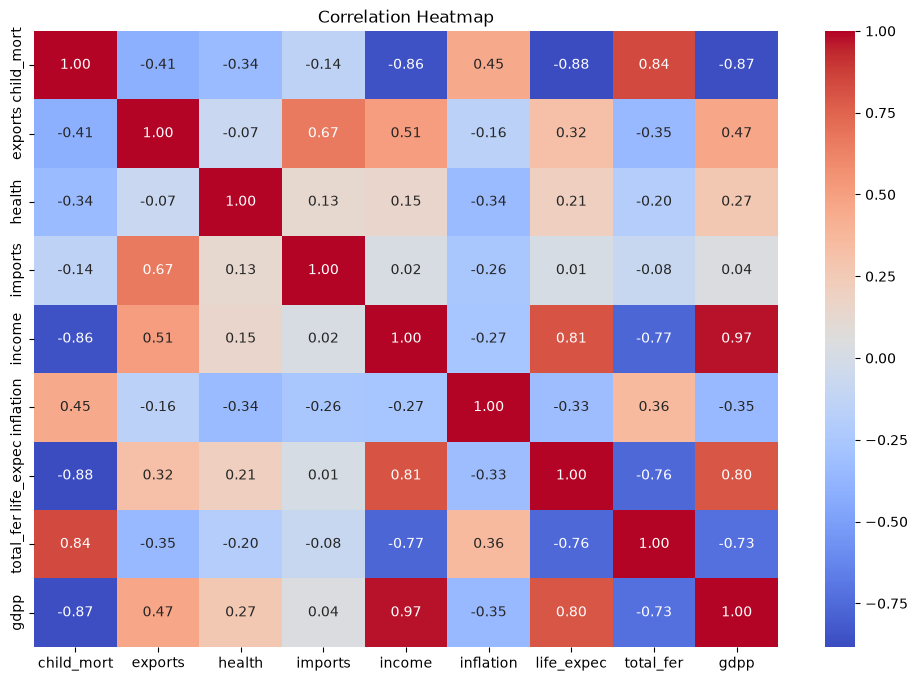

In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [28]:
print("correlation of the columns in the dataset: ", numerical_cols.corr())

correlation of the columns in the dataset:              child_mort   exports    health   imports    income  inflation  \
child_mort    1.000000 -0.318093 -0.200402 -0.127211 -0.524315   0.288276   
exports      -0.318093  1.000000 -0.114408  0.737381  0.516784  -0.107294   
health       -0.200402 -0.114408  1.000000  0.095717  0.129579  -0.255376   
imports      -0.127211  0.737381  0.095717  1.000000  0.122406  -0.246994   
income       -0.524315  0.516784  0.129579  0.122406  1.000000  -0.147756   
inflation     0.288276 -0.107294 -0.255376 -0.246994 -0.147756   1.000000   
life_expec   -0.886676  0.316313  0.210692  0.054391  0.611962  -0.239705   
total_fer     0.848478 -0.320011 -0.196674 -0.159048 -0.501840   0.316921   
gdpp         -0.483032  0.418725  0.345966  0.115498  0.895571  -0.221631   

            life_expec  total_fer      gdpp  
child_mort   -0.886676   0.848478 -0.483032  
exports       0.316313  -0.320011  0.418725  
health        0.210692  -0.196674  0.345966  
i

## Correlation Analysis

A correlation heatmap was generated to understand the relationships between economic, demographic, and health-related indicators.

Correlation values range from -1 to +1:

- +1 indicates a perfect positive relationship.
- -1 indicates a perfect negative relationship.
- 0 indicates no linear relationship.

The analysis helps identify variables that move together and provides insights into country development patterns.

- Insight:  Since the dataset does not contain a target (class) variable, there is no predefined outcome to predict. Therefore, the primary objective is to discover hidden patterns and group similar countries based on their socioeconomic indicators. Hence, the problem is initially approached as an unsupervised learning problem, where clustering techniques such as K-Means and DBSCAN are used for country segmentation.

#### Feature Engineering

In [29]:
# feature scaling
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

In [30]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [31]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}: {score}")

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [32]:
# testing
df.isnull().sum()


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     4
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [33]:
df[df.isnull().any(axis=1)]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
43,Czech Republic,1.481605,4.204693,7.88,4.157319,10.250652,NaN,77.5,1.51,9.893488
73,Ireland,1.648659,4.644391,9.19,4.471639,10.729875,NaN,80.4,2.05,10.793455
77,Japan,1.435085,2.772589,9.49,2.681022,10.485731,NaN,82.8,1.39,10.703267
131,Seychelles,2.734368,4.551769,3.40,4.691348,9.923339,NaN,73.4,2.17,9.287394


In [ ]:
! pip install turtle